# Cellcharter on slide-seq kidney data

In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

import json
from scipy import sparse
import os

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import scvi
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

Seed set to 12345
Seed set to 12345


In [3]:
initDir = '/nfs/team361/ms83/data/kidney/slideseq_cellcharter/compatible_anndata/'
outDir = '/nfs/team361/ms83/data/kidney/slideseq_cellcharter/'

## Load adata with scVI embeddings (cell charter uses them)

File I am using: "/nfs/team361/ms83/data/kidney/slideseq_scviva/adata_kidney_slideseq_all_preprocessed_scvi_emb.h5ad" but in its disassembled version.

In [4]:
def load_adata(input_directory: str) -> ad.AnnData:
    obs = pd.read_parquet(os.path.join(input_directory, "obs.parquet"))
    var = pd.read_parquet(os.path.join(input_directory, "var.parquet"))

    with open(os.path.join(input_directory, "uns.json"), "r") as file:
        uns = json.load(file)

    obsm_spatial = np.load(os.path.join(input_directory, "obsm_spatial.npy"))
    obsm_scVI = np.load(os.path.join(input_directory, "obsm_scVI.npy"))
    obsm_scANVI = np.load(os.path.join(input_directory, "obsm_scANVI.npy"))
    
    layers_counts = sparse.load_npz(os.path.join(input_directory, "layers_counts.npz"))

    x = sparse.load_npz(os.path.join(input_directory, "x.npz"))

    var_names = np.loadtxt(os.path.join(input_directory, "var_names.csv"), delimiter=",", dtype=str).tolist()
    obs_names = np.loadtxt(os.path.join(input_directory, "obs_names.csv"), delimiter=",", dtype=str).tolist()

    adata = ad.AnnData(X=x, obs=obs, var=var, uns=uns)
    adata.obsm["spatial"] = obsm_spatial
    adata.obsm["X_scVI"] = obsm_scVI
    adata.obsm["X_scANVI"] = obsm_scANVI
    adata.layers["counts"] = layers_counts
    adata.var_names = var_names
    adata.obs_names = obs_names

    return adata

In [5]:
adata = load_adata('/nfs/team361/ms83/data/kidney/slideseq_cellcharter/compatible_anndata/')

In [6]:
adata

AnnData object with n_obs × n_vars = 80499 × 13359
    obs: 'cell_id', 'Study_slice_id', 'NEMO_K_SLICE_ID', 'NEMO_K_PATIENT_ID', 'Corpus_ID', 'Study_patient_id', 'Data_source', 'Platform', 'Tissue_subregion', 'Status', 'Diagnosis', 'Type', 'Age', 'Age_grouping', 'Sex', 'eGFR', 'eGFR_group', 'BMI', 'Obesity_status', 'eGFR baseline', 'eGFR change', 'RCC_Treatment', 'batch', 'NEMO_cell_label', 'NEMO_neighborhood_label', 'tech', 'seed_labels', 'scANVI_pred', 'scANVI_confidence', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'umap'
    obsm: 'spatial', 'X_scVI', 'X_scANVI'
    layers: 'counts'

In [7]:
sq.gr.spatial_neighbors(adata, library_key='batch', coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)

In [8]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='batch')

100%|██████████| 4/4 [00:01<00:00,  3.22it/s]


In [9]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,10), 
    max_runs=10,
    convergence_tol=0.001
)

In [10]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:04<00:42,  4.21s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:07<00:34,  3.78s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:09<00:23,  2.95s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:16,  1.60s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:04<00:23,  2.61s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:08<00:24,  3.01s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 3/10


...

  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:01<00:13,  1.35s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:02<00:13,  1.49s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:06<00:18,  2.34s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 9/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:03<00:32,  3.27s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:07<00:32,  3.61s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:10<00:29,  3.69s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

Iteration 10/10


  0%|          | 0/11 [00:00<?, ?it/s]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
  9%|▉         | 1/11 [00:03<00:32,  3.22s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 18%|█▊        | 2/11 [00:06<00:29,  3.32s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 27%|██▋       | 3/11 [00:08<00:22,  2.86s/it]LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIB

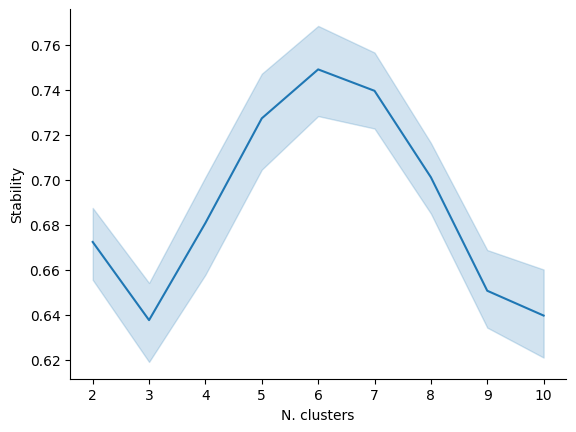

In [11]:
cc.pl.autok_stability(autok)

In [12]:
adata.obs['cluster_cellcharter'] = autok.predict(adata, use_rep='X_cellcharter')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [13]:
adata

AnnData object with n_obs × n_vars = 80499 × 13359
    obs: 'cell_id', 'Study_slice_id', 'NEMO_K_SLICE_ID', 'NEMO_K_PATIENT_ID', 'Corpus_ID', 'Study_patient_id', 'Data_source', 'Platform', 'Tissue_subregion', 'Status', 'Diagnosis', 'Type', 'Age', 'Age_grouping', 'Sex', 'eGFR', 'eGFR_group', 'BMI', 'Obesity_status', 'eGFR baseline', 'eGFR change', 'RCC_Treatment', 'batch', 'NEMO_cell_label', 'NEMO_neighborhood_label', 'tech', 'seed_labels', 'scANVI_pred', 'scANVI_confidence', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'umap', 'spatial_neighbors'
    obsm: 'spatial', 'X_scVI', 'X_scANVI', 'X_cellcharter'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [14]:
adata.write_h5ad(outDir + 'adata_kidney_slideseq_all_preprocessed_cellcharter_emb.h5ad')

In [15]:
adata.obs['batch'].value_counts()

batch
Puck_200903_05    23137
Puck_200903_03    21357
Puck_200903_01    18535
Puck_200903_02    17470
Name: count, dtype: int64

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


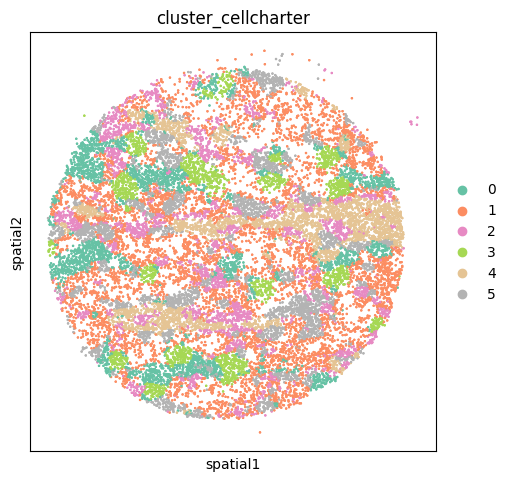

In [16]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='batch',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['Puck_200903_01'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


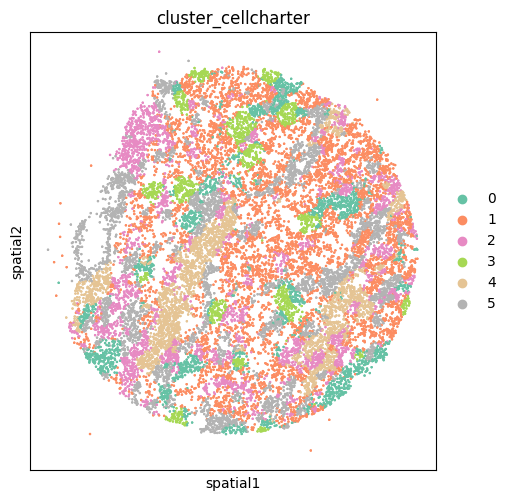

In [17]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='batch',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['Puck_200903_02'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


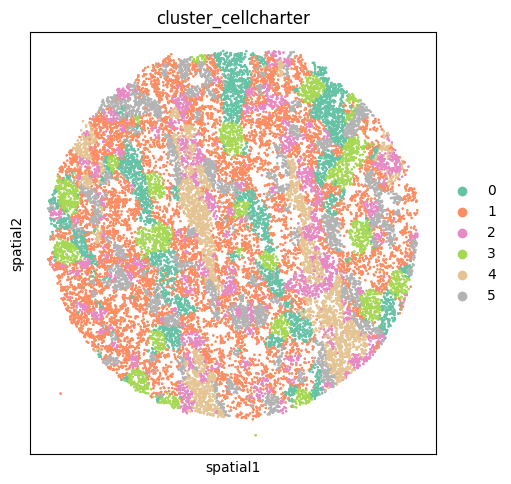

In [18]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='batch',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['Puck_200903_03'],
)

/software/cellgen/team361/ms83/envs/cellcharter-env2/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


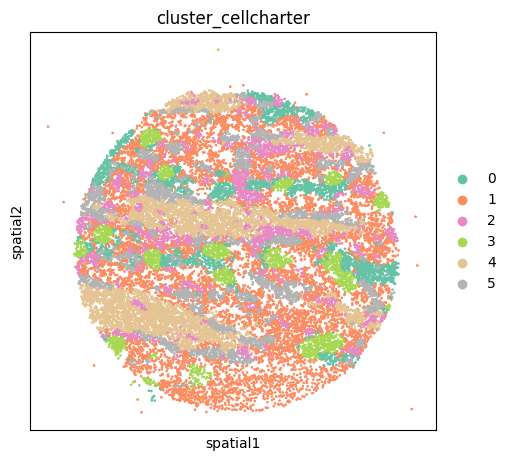

In [19]:
sq.pl.spatial_scatter(
    adata, 
    color=['cluster_cellcharter'], 
    library_key='batch',  
    size=2, 
    img=None,
    spatial_key='spatial',
    shape=None,
    palette='Set2',
    figsize=(5,5),
    ncols=1,
    library_id=['Puck_200903_05'],
)